In [1]:
import pandas as pd
import matplotlib.pyplot as plt


========== WEATHER DATA ==========
         Date   City  Temperature Weather
0  2026-06-01  Delhi           38   Sunny
1  2026-06-02  Delhi           40   Sunny
2  2026-06-03  Delhi           36   Rainy
3  2026-06-04  Delhi           39   Sunny
4  2026-06-05  Delhi           35  Cloudy

Dataset Shape:
(35, 4)

========== DATA CLEANING ==========

Missing Values:
Date           0
City           0
Temperature    0
Weather        0
dtype: int64

Duplicate Rows: 0

Data after cleaning:
        Date   City  Temperature Weather
0 2026-06-01  Delhi           38   Sunny
1 2026-06-02  Delhi           40   Sunny
2 2026-06-03  Delhi           36   Rainy
3 2026-06-04  Delhi           39   Sunny
4 2026-06-05  Delhi           35  Cloudy

========== AVERAGE TEMPERATURE ==========
City
Jaipur        40.29
Delhi         38.00
Chandigarh    34.00
Mumbai        30.86
Bangalore     27.43
Name: Temperature, dtype: float64

🔥 Hottest City:
Jaipur
Average Temperature: 40.29 °C

❄️ Coldest City:
Bangalore
Av

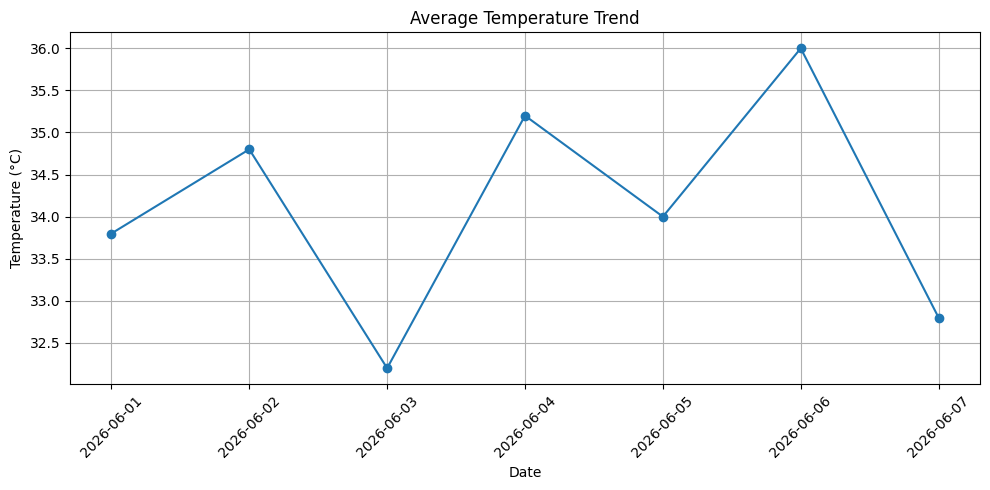

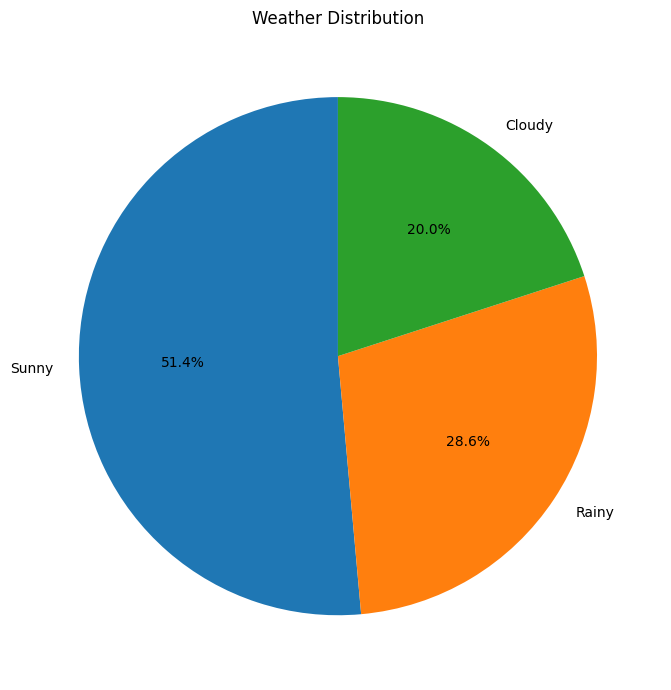

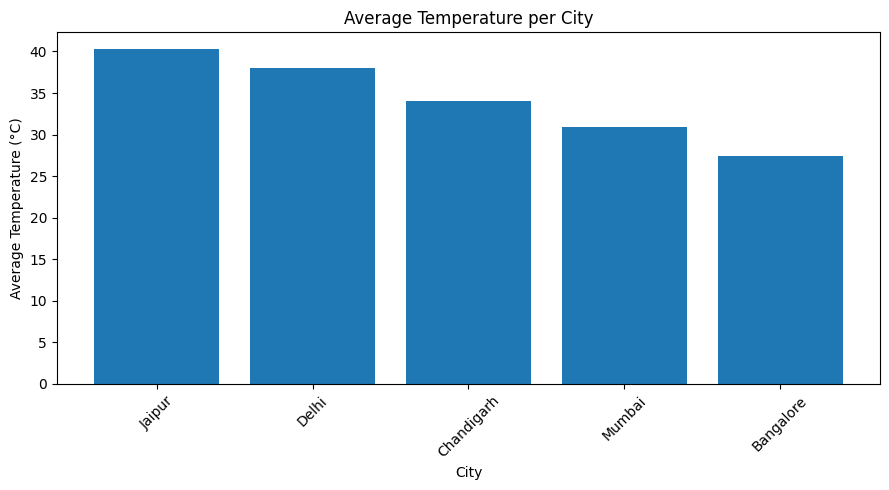


========== TEMPERATURE PREDICTION ==========
Predicted temperature for tomorrow: 34.27 °C

========== FINAL REPORT ==========
         City  Average_Temperature Temperature_Status
0      Jaipur            40.285714            Hottest
1       Delhi            38.000000             Normal
2  Chandigarh            34.000000             Normal
3      Mumbai            30.857143             Normal
4   Bangalore            27.428571            Coldest

✅ Final report exported successfully!
File: final_weather_report.csv

========== PROJECT SUMMARY ==========
Total Records: 35
Number of Cities: 5
Hottest City: Jaipur
Coldest City: Bangalore
Rainy Days: 10
Sunny Days: 18
Tomorrow's Predicted Temperature: 34.27 °C

🎉 WEATHER ANALYTICS PROJECT COMPLETED!


In [ ]:
df = pd.read_csv("weather_data.csv")

print("\n========== WEATHER DATA ==========")
print(df.head())

print("\nDataset Shape:")
print(df.shape)



print("\n========== DATA CLEANING ==========")

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

# Remove rows containing missing values
df = df.dropna()

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("\nData after cleaning:")
print(df.head())



print("\n========== AVERAGE TEMPERATURE ==========")

average_temperature = (
    df.groupby("City")["Temperature"]
    .mean()
    .sort_values(ascending=False)
)

print(average_temperature.round(2))



hottest_city = average_temperature.idxmax()
hottest_temperature = average_temperature.max()

print("\n🔥 Hottest City:")
print(hottest_city)

print("Average Temperature:",
      round(hottest_temperature, 2), "°C")



coldest_city = average_temperature.idxmin()
coldest_temperature = average_temperature.min()

print("\n❄️ Coldest City:")
print(coldest_city)

print("Average Temperature:",
      round(coldest_temperature, 2), "°C")



rainy_days = len(
    df[df["Weather"].str.lower() == "rainy"]
)

sunny_days = len(
    df[df["Weather"].str.lower() == "sunny"]
)

print("\n========== WEATHER DAYS ==========")

print("🌧 Rainy Days:", rainy_days)
print("☀ Sunny Days:", sunny_days)



daily_temperature = (
    df.groupby("Date")["Temperature"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    daily_temperature.index,
    daily_temperature.values,
    marker="o"
)

plt.title("Average Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig("temperature_trend.png")

plt.show()



weather_distribution = df["Weather"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    weather_distribution.values,
    labels=weather_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Weather Distribution")

plt.tight_layout()

plt.savefig("weather_distribution.png")

plt.show()



plt.figure(figsize=(9, 5))

plt.bar(
    average_temperature.index,
    average_temperature.values
)

plt.title("Average Temperature per City")
plt.xlabel("City")
plt.ylabel("Average Temperature (°C)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("average_temperature_city.png")

plt.show()


# ==========================================
# 10. BONUS - MOVING AVERAGE
# ==========================================

print("\n========== TEMPERATURE PREDICTION ==========")

# Calculate daily average temperature
daily_temperature = (
    df.groupby("Date")["Temperature"]
    .mean()
    .sort_index()
)

# 3-day moving average
moving_average = daily_temperature.rolling(
    window=3
).mean()

# Last moving average value
tomorrow_temperature = moving_average.iloc[-1]

print(
    "Predicted temperature for tomorrow:",
    round(tomorrow_temperature, 2),
    "°C"
)


# ==========================================
# 11. CREATE FINAL REPORT
# ==========================================

final_report = average_temperature.reset_index()

final_report.columns = [
    "City",
    "Average_Temperature"
]

# Add hottest/coldest information
final_report["Temperature_Status"] = final_report[
    "City"
].apply(
    lambda city:
    "Hottest"
    if city == hottest_city
    else "Coldest"
    if city == coldest_city
    else "Normal"
)

# Export report
final_report.to_csv(
    "final_weather_report.csv",
    index=False
)

print("\n========== FINAL REPORT ==========")

print(final_report)

print("\n✅ Final report exported successfully!")

print("File: final_weather_report.csv")


# ==========================================
# 12. PROJECT SUMMARY
# ==========================================

print("\n========== PROJECT SUMMARY ==========")

print("Total Records:", len(df))

print("Number of Cities:",
      df["City"].nunique())

print("Hottest City:",
      hottest_city)

print("Coldest City:",
      coldest_city)

print("Rainy Days:",
      rainy_days)

print("Sunny Days:",
      sunny_days)

print(
    "Tomorrow's Predicted Temperature:",
    round(tomorrow_temperature, 2),
    "°C"
)

print("\n🎉 WEATHER ANALYTICS PROJECT COMPLETED!")